# Wave with Dirichlet bc using amplitude and phase functions.

We solve the wave equation with Dirichlet boundary conditions (homogeneous) up to $T = 2L$ where $L$ is the size of the integrating region. The data is reflection symmetric, $u_0(x) = u_0(L-x)$, $\partial_t u(x,t=0) = 0$. This way at the last point the solution repeats itself and we can measure the error very well. We do this introducing two functions for the field, corresponding to a phase and and amplitude. 


$$
u(t,x) = Real(A(t,x)*e^(iϕ(t,x)))
$$
Implemented as: 

$$
u(t,x) = A(t,x)*cos(ϕ(t,x)) + B(t,x)*sin(ϕ(t,x))
$$

In [1]:
import Pkg
#Pkg.add("Zygote")
#Pkg.instantiate()
#Pkg.add("StatsBase")
#Pkg.add("UnPack")
#Pkg.add("Revise")
using ComponentArrays
using Distributions
#using WGLMakie
using Lux
using LuxCUDA
using Flux #for the modified architecture
using Optim
using OptimizationOptimJL
using Random
using UnPack
using Zygote
#using CairoMakie  # Backend que funciona en notebooks
using StatsBase
using Revise
using Plots
using JLD2
using NBInclude
#import NaNMath

## Status:

Working well in both GPU and CPU without adaptivity. Using both initial data for u and its derivative.

I put some functions here.

In [2]:
includet("../../neural_tools.jl")
includet("config.jl")

┌ Warning: The use of `Flux.@functor` is deprecated.
│ Most likely, you should write `Flux.@layer MyLayer`which will add various convenience methods for your type,such as pretty-printing and use with Adapt.jl.
│ However, this is not required. Flux.jl v0.15 uses Functors.jl v0.5,which makes exploration of most nested `struct`s opt-out instead of opt-in...so Flux will automatically see inside any custom struct definitions.
│ If you really want to apply the `@functor` macro to a custom struct, use `Functors.@functor` instead.
└ @ Flux /Users/reula/.julia/packages/Flux/uRn8o/src/deprecations.jl:101


In [3]:

config = config_geo
#config = config_test  # switch to config for real run

@show get_parameter_count(config)


get_parameter_count(config) = 1383


1383

**Note 1:** 
**Note 2:** 

In [4]:
# -------------------------------------------------------------------
# Second order wave equation (onda 1D): u_tt - c^2 u_xx = 0
# -------------------------------------------------------------------

function wave_equation(∂2u_∂x2, ∂2u_∂t2, config) 
    c = config[:c]
    ∂2u_∂t2 .- (c^2) .* ∂2u_∂x2
end

```
Residual at collocation points
``` 

function residual_at_points_Dirichlet(input, NN, Θ, st)
    x, t = input[1:1, :], input[2:2, :]
    _, u_xx, u_tt = calculate_derivatives_Dirichlet_geo(x, t, NN, Θ, st)
    res = wave_equation(u_xx, u_tt, config) 
    abs_res = (abs.(u_xx) .+ abs.(u_tt))
    res = res ./ abs_res
    #res = wave_equation(u_xx, u_tt, config)
    #return vec(abs.(res |> cpu_device()))  # magnitud del residuo en CPU
    #return vec(abs.(res))
    return res
end


# -------------------------------------------------------------------
# Loss function with Dirichlet boundary conditions hard enforced.
# -------------------------------------------------------------------

function loss_function(input, NN, Θ, st)
    res = residual_at_points_Dirichlet(input[1], NN, Θ, st)
    #return log10(sum(abs2, res) / length(res))
    #return log10(sum(abs, res) / length(res))
    return sum(abs2, res) / length(res)
end

# -------------------------------------------------------------------
# Callback
# -------------------------------------------------------------------
function callback(p, l, losses)
    println("Current loss: ", l)
    push!(losses, log10(l))
    return false
end

callback (generic function with 1 method)

In [5]:
#loss_function(input_total, NN, Θ, st)

Initial data:

In [5]:
includet("wave_ini_bound_data.jl")

#plot(u0, xmin, xmax, title="Initial displacement u0(x) and velocity u1(x)", xlabel="x", ylabel="u0/u1", label="u0")
#plot!(u1, xmin, xmax, label="u1")

### Results:

1. With the p=4 polynomial data works OK and the error is of low frequency.
2. With the p=2 sin data it does not work. Start decreasing the loss function but at some point there is a problem with the optimizer and it does not improve further, on the contrary the loss stabilizes in a larger value.
It seems to be going with smaller t evolution (as if the speed were smaller)
3. We tried with rescaling the residual by the norm of the derivatives, but it does not work with SSB nor with the log10 transformation. It works very slowly with BB. 
4. With less points it seems to work (p=8), although it takes a lot of iterations and after many iterations the error is still large. I tried with Adams too. 


In [6]:
input = generate_input_x_t(config)
input0 = generate_input0_x(config)
input_bound = generate_input_boundary_x(config)
input_total = [input, input0, input_bound]

@show typeof(input_total) size(input_total)
@show get_parameter_count(config)

#input_cpu = input |> cpu_device()

# plot the inputs is needed
#scatter(input_cpu[1,:], input_cpu[2,:], markersize=1, title="Collocation points", xlabel="x", ylabel="t")

┌ Warning: No functional GPU backend found! Defaulting to CPU.
│ 
│ 1. If no GPU is available, nothing needs to be done. Set `MLDATADEVICES_SILENCE_WARN_NO_GPU=1` to silence this warning.
│ 2. If GPU is available, load the corresponding trigger package.
│     a. `CUDA.jl` and `cuDNN.jl` (or just `LuxCUDA.jl`) for  NVIDIA CUDA Support.
│     b. `AMDGPU.jl` for AMD GPU ROCM Support.
│     c. `Metal.jl` for Apple Metal GPU Support. (Experimental)
│     d. `oneAPI.jl` for Intel oneAPI GPU Support. (Experimental)
└ @ MLDataDevices.Internal /Users/reula/.julia/packages/MLDataDevices/NeohJ/src/internal.jl:112


typeof(input_total) = Vector{Array{Float64}}
size(input_total) = (3,)
get_parameter_count(config) = 1383


1383

In [7]:
# -------------------------------------------------------------------
# Entrenamiento
# -------------------------------------------------------------------
losses = []
NN, Θ, st = create_neural_network(config)


#input_total[1] === input

(Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_4::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_5::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}((layer_1 = Dense(2 => 20, tanh), layer_2 = Dense(20 => 20, tanh), layer_3 = Dense(20 => 20, tanh), layer_4 = Dense(20 => 20, tanh), layer_5 = Dense(20 => 3)), nothing), (layer_1 = (weight = [0.7326929569244385 -1.3635015487670898; 1.4616241455078125 1.3009198904037476; … ; -0.5613917112350464 -1.682041049003601; -0.45638296008110046 -0.3056337833404541], bias = [0.0189228393137455, 0.4488125145435333, -0.48071447014808655, -0.36183127760887146, 0.2613581717014313, -0.03760502114892006, -0.11283747851848602, 0.6132303476333618, 0.7063409686088562, -0.575527787208

In [9]:
#res = residual_at_points_Dirichlet(input_total[1], NN, Θ, st)
#res_cpu = res |> cpu_device()
#@show typeof(res_cpu) size(res_cpu)
#res_cpu

In [8]:
loss_function(input_total, NN, Θ, st)

0.9997380373215156

In [11]:


#calculate_Dirichlet_f(input[1:1, :], input[2:2, :], NN, Θ, st)
#f, ∂2f_∂x2, ∂2f_∂t2 = calculate_derivatives_Dirichlet(input[1:1, :], input[2:2, :], NN, Θ, st)

In [9]:
Θ, st, losses = compute_solution_1d(config, input_total, NN, Θ, st, losses)

┌ Info: Normal training round 1 / 20  |  iters=2000
└ @ Main /Users/reula/Julia/PINN/neural_tools.jl:651


Current loss: 0.9997380373215156
Current loss: 0.9990418106706817
Current loss: 0.9986951552647969
Current loss: 0.8815923835999847
Current loss: 0.8675505642385413
Current loss: 0.760053958660841


┌ Warning: a < 0 detected in update_h!. Setting tau = 1 and phi = 1.
└ @ Optim /Users/reula/.julia/packages/Optim/7DdDW/src/multivariate/solvers/first_order/ssbroyden.jl:169


Current loss: 0.7600539586344309
Current loss: 0.7600539587529074
Current loss: 0.7600539587461385
Current loss: 0.7600539586601355
Current loss: 0.7600539586177859
Current loss: 0.7600539587640749
Current loss: 0.7600539585745273
Current loss: 0.7600539585757088


┌ Warning: a < 0 detected in update_h!. Setting tau = 1 and phi = 1.
└ @ Optim /Users/reula/.julia/packages/Optim/7DdDW/src/multivariate/solvers/first_order/ssbroyden.jl:169
┌ Warning: a < 0 detected in update_h!. Setting tau = 1 and phi = 1.
└ @ Optim /Users/reula/.julia/packages/Optim/7DdDW/src/multivariate/solvers/first_order/ssbroyden.jl:169


...

┌ Warning: a < 0 detected in update_h!. Setting tau = 1 and phi = 1.
└ @ Optim /Users/reula/.julia/packages/Optim/7DdDW/src/multivariate/solvers/first_order/ssbroyden.jl:169
┌ Warning: a < 0 detected in update_h!. Setting tau = 1 and phi = 1.
└ @ Optim /Users/reula/.julia/packages/Optim/7DdDW/src/multivariate/solvers/first_order/ssbroyden.jl:169


Current loss: 0.7702930336210916
Current loss: 0.7702930334910367
Current loss: 0.7702930336210916
Current loss: 

┌ Warning: a < 0 detected in update_h!. Setting tau = 1 and phi = 1.
└ @ Optim /Users/reula/.julia/packages/Optim/7DdDW/src/multivariate/solvers/first_order/ssbroyden.jl:169


0.7702930334910367
Current loss: 0.7702930336210916
Current loss: 0.7702930335725812
Current loss: 0.7702930335712692
Current loss: 0.7702930335138951
Current loss: 0.7702930335505612


((layer_1 = (weight = [0.7326929569244385 -1.3635015487670898; 1.4616241455078125 1.3009198904037476; … ; -0.5613917112350464 -1.682041049003601; -0.45638296008110046 -0.3056337833404541], bias = [0.0189228393137455, 0.4488125145435333, -0.48071447014808655, -0.36183127760887146, 0.2613581717014313, -0.03760502114892006, -0.11283747851848602, 0.6132303476333618, 0.7063409686088562, -0.5755277872085571, -0.16949447989463806, -0.38164788484573364, 0.22344496846199036, 0.3015982210636139, 0.5451110601425171, -0.36809659004211426, 0.6270377039909363, -0.15569981932640076, -0.3591761887073517, 0.5852583050727844]), layer_2 = (weight = [-0.1755068004131317 -0.38013890385627747 … 0.5428467392921448 0.33334881067276; 0.42852652072906494 -0.2847967743873596 … -0.23239946365356445 -0.30740806460380554; … ; -0.0011927136220037937 -0.6122130155563354 … -0.484098345041275 0.10910789668560028; 0.36094945669174194 -0.38019445538520813 … 0.3559945225715637 0.3351952135562897], bias = [-0.2005614489316

In [13]:
# Parámetros optimizados a CPU si procede
Θ_cpu = Θ |> cpu_device()

ComponentVector{Float64}(layer_1 = (weight = [-0.5385162830352783 0.8593049645423889; -0.8965945839881897 1.8887602090835571; … ; 1.3959101438522339 -1.907496690750122; 1.4917079210281372 1.466637372970581], bias = [-0.4994470775127411, 0.647781491279602, -0.509484589099884, 0.1308613270521164, -0.06388088315725327, -0.537559449672699, 0.6519004106521606, 0.15232494473457336, -0.5253828167915344, -0.29811519384384155, -0.40142184495925903, 0.6660487651824951, -0.07884444296360016, -0.41640201210975647, -0.058804549276828766, 0.5565255284309387, 0.16268935799598694, 0.21216647326946259, -0.03406291455030441, -0.6633093953132629]), layer_2 = (weight = [0.20194710791110992 -0.47679662704467773 … 0.31097689270973206 0.04642980173230171; 0.28923195600509644 0.21400760114192963 … -0.4896937310695648 -0.273511677980423; … ; 0.018284376710653305 0.17868149280548096 … 0.2640042304992676 0.3732753396034241; -0.03259485960006714 0.377696692943573 … 0.03628319501876831 -0.6227075457572937], bias =

**Save data:**

In [14]:
println("Training completed. Saving data")
#@save "wave_Dir_1.jld2" config Θ_cpu st losses
#@save "wave_dirichlet_1D_adaptive.jld2" Θ_cpu st config losses
#@save "wave_dirichlet_1D_u0_sin_u1_zero_p8_SSB.jld2" Θ_cpu st config losses
@save "wave_dirichlet_1D_geo_u0_sin_u1_zero_p8_BB.jld2" Θ_cpu st config losses
#@save "wave_dirichlet_1D_test.jld2" Θ_cpu st config losses 

if in_nbinclude()
    exit()
end

Training completed. Saving data


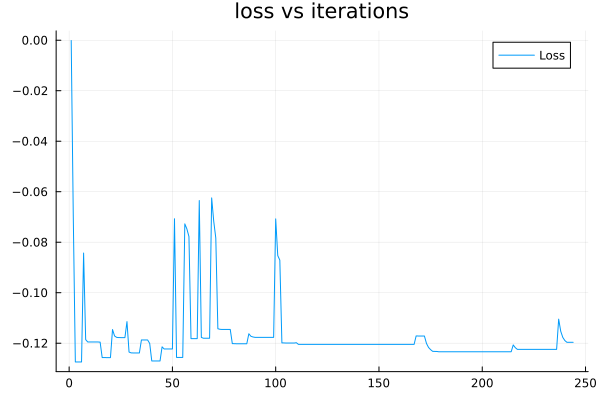

In [15]:
plot(losses, label = "Loss", title = "loss vs iterations") #, yscale = :log10)


In [16]:
losses

config[:tmax]

2.0

In [17]:
NN = create_chain(config)

Chain(
    layer_1 = Dense(2 => 20, tanh),               # 60 parameters
    layer_(2-4) = Dense(20 => 20, tanh),          # 1_260 (420 x 3) parameters
    layer_5 = Dense(20 => 3),                     # 63 parameters
)         # Total: 1_383 parameters,
          #        plus 0 states.

For the initial data with $u_1(x) = \partial_x u_0(x)$ the solution is:

$$ 
u(x,t) = 
\begin{cases}
& u_0(x+t) \;\;\;\; t \leq x \;\;\text{and} \;\;  t \leq 1 - x \\
& u_0(x+t) - u_0(x-t) \;\;\;\;\; t \geq x \;\; \text{and} \;\; t \leq 1 - x \\
& 0 \;\;\;\;\; t \leq x \;\; \text{and} \;\; t \geq 1 - x \\
& - u_0(x-t) \;\;\;\;\; t \geq x \;\; \text{and} \;\; t \geq 1 - x ;\; \text{and} \;\; t \leq 1 + x \\
\end{cases} 
$$

In [18]:
#@unpack xmin, xmax, A, B, p = config
t = 2.
xs = reshape(collect(range(config[:xmin], config[:xmax], length=200)), 1, :)
t_fix = reshape(fill(t, length(xs)), 1, :)
#sol_p = [calculate_Dirichlet_f(xs, t_fix, NN, Θ, st) for x in xs]
sol_p = [calculate_Dirichlet_f_wf(xs[:,i], t_fix[:,i], NN, Θ_cpu, st)[1] for i in 1:length(xs[1,:])]

plot(xs[1,:],sol_p, label = "approximatio at t=$t", title = "solution")
#lines!(xs[1,:],bump.(xs[1,:], config[:x0], config[:x1], config[:p], config[:A]), label = "initial condition")
plot!(xs[1,:],u0(xs[1,:]), label = "initial condition", linestyle = :dash)  
plot!(xlabel = "x", ylabel = "u(x,t)")   
plot!(xs[1,:], A*(sin.(2π*(xs[1,:].+t)*p/(xmax - xmin)) + sin.(2π*(xs[1,:].-t)*p/(xmax - xmin)))/2, label = "exact solution at t = $t")  # exact solution at t=2.0


DimensionMismatch: DimensionMismatch: a has size (1,), b has size (3,), mismatch at dim 1

In [19]:
ax = (title = "solution")
t = 2.0
xs = reshape(collect(range(config[:xmin], config[:xmax], length=20000)), 1, :)
t_fix = reshape(fill(t, length(xs)), 1, :)
sol_p = [calculate_Dirichlet_f_wf(xs[:,i], t_fix[:,i], NN, Θ_cpu, st)[1] for i in 1:length(xs[1,:])]

plot(xs[1,:],sol_p .- u0.(xs[1,:]), label = "eror at t=1")

DimensionMismatch: DimensionMismatch: a has size (1,), b has size (3,), mismatch at dim 1